In [2]:
library(readr)
library(dplyr)
library(rsample)
library(smotefamily)
library(janitor)
library(ggplot2)
library(randomForest)
library(shapviz)
library(treeshap)
library(caret)
library(xgboost)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test


randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:ggplot2’:

    margin


The following object is masked from ‘package:dplyr’:

    combine


Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:rsample’:

    calibration




### Data Cleaning/Preparing - will need test and training set to create plots

We set some global parmeter for the tree model.

In [3]:
# DATA RELATED PARAMS
def_outbreak = 4 # number of cases to be considered as outbreak
perc_strata = 0.75 # proportion of data to be used for training

# SMOTE RELATED PARAMS
K_neighbors = 5 # number of nearest neighbors
Ratio_testtrain = 0 # for 50/50 outbreak/non-outbreak

In [4]:
drop_redundant_yn_features <- function(df) {
  # Get all column names
  cols <- names(df)
  
  # Find Yes/No pairs by stripping the suffix
  yes_cols <- cols[grepl("_yes", cols)]
  no_cols  <- cols[grepl("_no",  cols)]
  
  # Get base names for each
  yes_bases <- sub("_diff$", "", sub("_yes", "", yes_cols))
  no_bases  <- sub("_diff$", "", sub("_no",  "", no_cols))
  
  # Find bases that have BOTH a Yes and No column
  paired_bases <- intersect(yes_bases, no_bases)
  
  cols_to_drop <- c()
  
  for (base in paired_bases) {
    yes_col <- yes_cols[yes_bases == base]
    no_col  <- no_cols[no_bases == base]
    
    # Count NAs in each
    yes_nas <- sum(is.na(df[[yes_col]]))
    no_nas  <- sum(is.na(df[[no_col]]))
    
    # Drop whichever has more NAs 
    # If tied drop "No" (keep "Yes")
    if (no_nas >= yes_nas) {
      cols_to_drop <- c(cols_to_drop, no_col)
    } else {
      cols_to_drop <- c(cols_to_drop, yes_col)
    }
  }
  
  cat("Dropping", length(cols_to_drop), "redundant columns:\n")
  #cat(paste(" ", cols_to_drop), sep = "\n")
  
  df[, !names(df) %in% cols_to_drop]
}

In [5]:
set.seed(100)

df <- read_csv("data/merged_with_svi.csv", show_col_types = FALSE) |> clean_names() 
#df <- read_csv("data/merged_with_svi.csv") |> clean_names()

# outbreak >=2 is with outbreak, vice versa.
# df$outbreak <- as.integer(df$outbreak >= def_outbreak)

# SVI specific, because it does not include the data for Mcculloch, Mclennan, Mcmullen and Dewitt, 
# if we continue the prev way of data processing it will remove all SVI related features, so we remove these 4 counties.
#df <- df[!df$county %in% c("Mcculloch", "Mclennan", "Mcmullen", "Dewitt"), ]

df <- df %>% filter(!county %in% c("Mcculloch", "Mclennan", "Mcmullen", "Dewitt", "Loving"))
df_raw <- df
df$density <- df$population*1.0/df$area_sqmi
df <- df %>% select(-c("county", "phr", "area_sqmi"), -starts_with("m_"), -starts_with("mp_"), -starts_with("e_"), -starts_with("epl_"), -starts_with("spl_"), -starts_with("rpl_"), -starts_with("f_"))
df <- df %>% select(-c("ep_minrty", "ep_hisp", "ep_afam", "ep_pov150", "ep_uninsur"))
df <- df[,colSums(is.na(df)) == 0]

df <- drop_redundant_yn_features(df)

# split the data with stratified sampling
# strata <- ifelse(df$outbreak > 0, "nonzero", "zero")
index <- createDataPartition(df$outbreak, p = perc_strata, list = FALSE)
train <- df[index,]
test <- df[-index,]

Dropping 82 redundant columns:


In [6]:
#train <- train[, colSums(is.na(train)) == 0]
#train <- train[, !names(train) %in% c("county")]

# Classify as outbreak of not
train$outbreak  <- as.integer(train$outbreak >= def_outbreak)

In [7]:
set.seed(42)
# K for controlling the neighborhood, dup_size for ratio to achieve

smote_output <- SMOTE(
  X      = train[, names(train) != "outbreak"],
  target = train$outbreak,
  K      = K_neighbors, 
  dup_size = Ratio_testtrain
)

train_balanced <- smote_output$data
# SMOTE put target data in "class" col and rename it
names(train_balanced)[names(train_balanced) == "class"] <- "outbreak"
train_balanced$outbreak <- as.factor(train_balanced$outbreak)
cat("\nClass balance after SMOTE:\n")
print(table(train_balanced$outbreak))
head(train_balanced)

# mirror on test set
test <- test[, names(train)]
test <- test[, !names(test) %in% c("county")]
test$outbreak <- as.integer(test$outbreak >= def_outbreak)



Class balance after SMOTE:

  0   1 
177 170 


cve,enrollment,population,pct_hispanic,pct_black,pct_white,pct_poverty,pct_uninsured,pct_college,pct_foreign_born,⋯,ep_noveh,ep_groupq,ep_noint,ep_asian,ep_aian,ep_nhpi,ep_twomore,ep_otherrace,density,outbreak
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
4.55,666,2596,60.2,4.9,42.7,23.2,27.2,8.2,1.1,⋯,6.0,6.2,23.1,0.0,0.0,0.0,0.8,0.1,3.349323,1
14.54,3764,23167,40.3,2.1,70.2,4.5,36.7,11.7,1.4,⋯,4.1,0.7,18.3,0.9,0.5,0.0,0.6,0.2,15.420380,1
5.00,7416,44174,10.4,7.2,79.3,10.1,13.8,18.2,0.9,⋯,3.9,1.2,13.0,0.5,0.1,0.1,3.3,0.2,75.772807,1
2.42,33445,184344,46.0,7.2,55.9,8.9,14.5,31.0,1.1,⋯,4.7,1.1,11.6,1.9,0.2,0.0,2.1,0.1,204.745409,1
4.08,2117,11655,55.8,6.7,49.5,16.9,22.5,12.7,0.4,⋯,8.3,14.5,16.2,0.2,0.3,0.0,2.0,0.0,12.945605,1
4.12,5523,39397,13.1,5.9,81.2,9.1,14.3,19.5,0.7,⋯,3.2,8.6,19.7,0.4,0.4,0.1,3.4,0.1,44.224838,1


#### Loading models - Classification

In [9]:
dtree_model <- readRDS("data/results/models/dtree_cl_svi_FINAL.rds")
rforest_model <- readRDS("data/results/models/rforest_cl_svi_FINAL.rds")
boost_model <- readRDS("data/results/models/boost_cl_svi_FINAL.rds")

### Loading Variables Models used - Classification

In [10]:
dtree_vars <- read_csv("data/results/merged_w_svi/important_vars_dtree_phr.csv")

rforest_vars <- read_csv("data/results/merged_w_svi/important_vars_rforest_phr.csv")

boost_vars <- read_csv("data/results/merged_w_svi/important_vars_boost_phr.csv")

Rows: 21 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): Variable
dbl (1): Importance

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 249 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): ...1
dbl (4): 0, 1, MeanDecreaseAccuracy, MeanDecreaseGini

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 54 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): Feature
dbl (4): ...1, Gain, Cover, Frequency

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FAL

### SHAP Library for Visual Plots

In [ ]:
#variables needed for plots

y_test  <- as.numeric(as.character(train$outbreak))

#Random Forest
c <- 0.4
cutoff <- c(c, 1-c)
#predicted results of Random Forest model
pred_rf <- predict(rforest_model, newdata = test, type = "class", cutoff=c(c, 1-c))

#XGBoost
cutoff_xgb <- 0.5
X_train <- as.matrix(train_balanced[, names(train_balanced) != "outbreak"])
y_train <- as.numeric(as.character(train_balanced$outbreak))

X_test  <- as.matrix(test[, names(test) != "outbreak"])
y_test  <- as.numeric(as.character(test$outbreak))

dtrain  <- xgb.DMatrix(data = X_train, label = y_train)
dtest   <- xgb.DMatrix(data = X_test,  label = y_test)

pred_xgb <- as.integer(predict(boost_model, dtest)>= cutoff_xgb)

In [48]:
# Converts the entire grid into one long basic vector
vect <- as.vector(as.matrix(pred_rf))
vect

[1] "0" "0" "0" "0" "0" "0" "0" "0" "0" "0" "0" "0" "0" "0" "0" "0" "0" "0" "0"
[20] "0" "0" "1" "0" "0" "0" "0" "0" "0" "0" "0" "0" "0" "0" "0" "0" "0" "0" "0"
[39] "0" "0" "0" "0" "0" "0" "0" "1" "0" "0" "0" "0" "0" "0" "1" "0" "0" "0" "0"
[58] "0" "0" "0" "0" "0"

#### Random Forest Plots

In [187]:
#Beeswarm SHAP for the random forest

feat       <- setdiff(names(test), "outbreak")
X_train_df <- as.data.frame(train_balanced[, feat])   # predictors the forest was trained on
X_expl     <- as.data.frame(test[, feat])             # rows to explain (test set)

unified <- randomForest.unify(rforest_model, X_train_df)
ts      <- treeshap(unified, X_expl)
shp_rf  <- shapviz(ts, X = X_expl)

|0%----|------|20%---|------|40%---|------|60%---|------|80%---|------|100%


In [203]:
#common variables among all models
vars <- c("enrollment", "overweight_or_obese_yes_pct_diff", "pct_black",
          "ep_munit", "ep_age65", "density", "any_cancer_yes", "population",
          "pct_uninsured", "ep_hburd", "ep_otherrace")

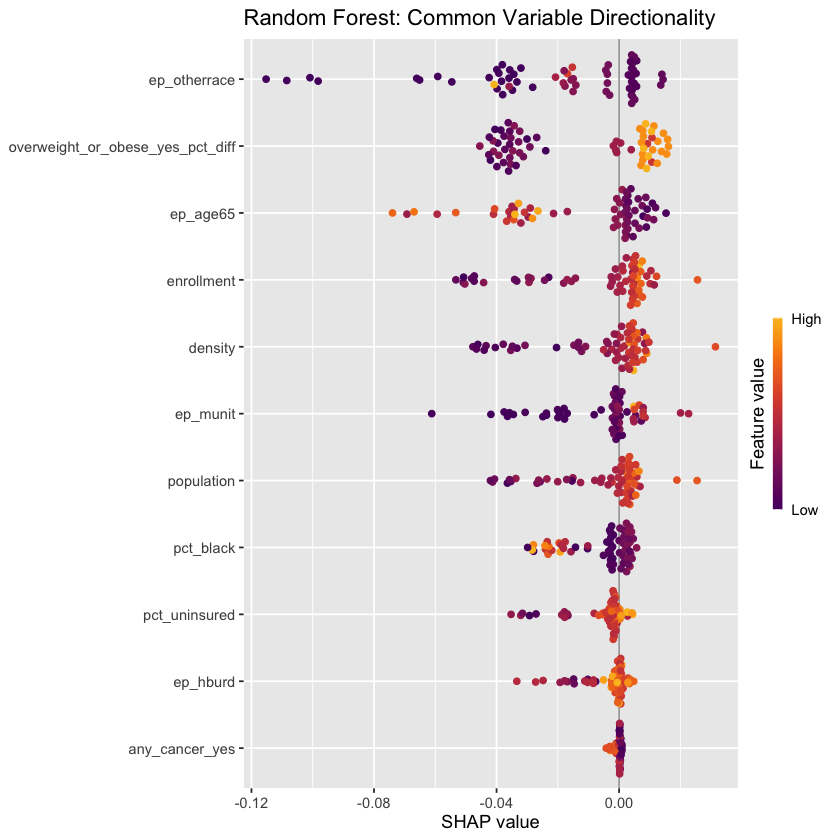

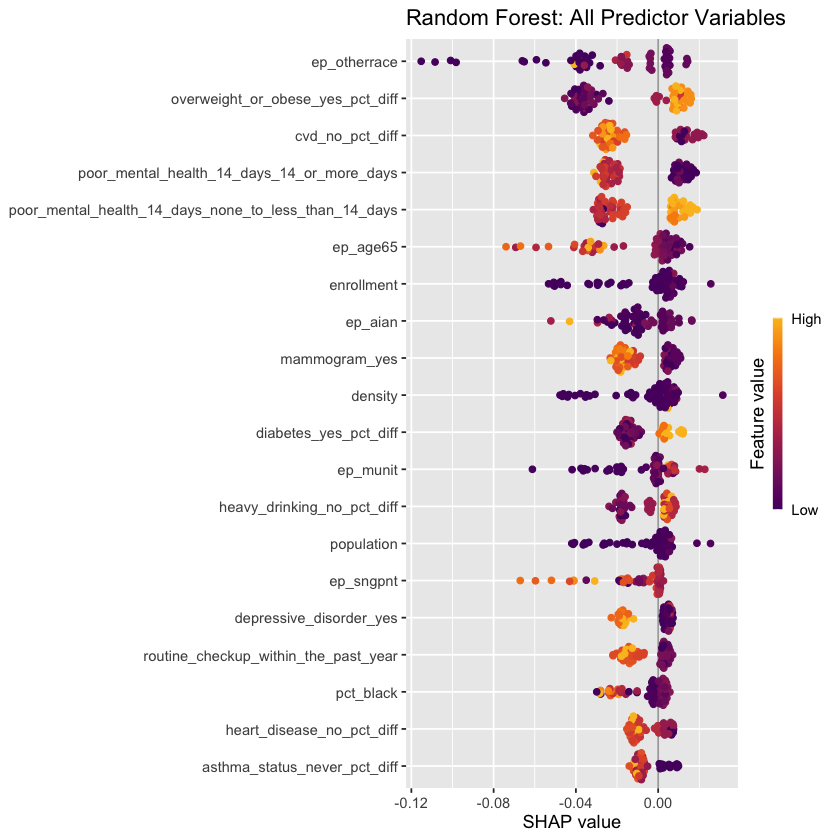

In [212]:
X <- get_feature_values(shp_rf)
log_vars <- intersect(c("enrollment", "density", "population"),
                      colnames(shp_rf))

for (v in log_vars) {
  X[[v]] <- log1p(X[[v]])   #log1p = log(1 + x); avoids -Inf if any value is 0
}

shp_rf_log <- shapviz(
  get_shap_values(shp_rf),
  X        = X,
  baseline = get_baseline(shp_rf)
)

#changing feature names
shp_rf_log_vars <- shp_rf_log[, vars]
colnames(shp_rf_log_vars) <- c("K-12 enrollment",
                               "increase of overweight/obese %",
                               "% of black residents",
                               "estimated % of multi unit housing",
                               "% of residents age 65 and older",
                               "density",
                               "has had cancer",
                               "population",
                               "uninsured %",
                               "% of housing burden",
                               "% of other races")


shp_rf_log_vars <- shp_rf_log[, vars]
sv_importance(shp_rf_log_vars, kind = "beeswarm", max_display = 15) +
  ggtitle("Random Forest: Common Variable Directionality")

#all predictor variables
sv_importance(shp_rf, kind = "beeswarm", max_display = 20) +
  ggtitle("Random Forest: All Predictor Variables")

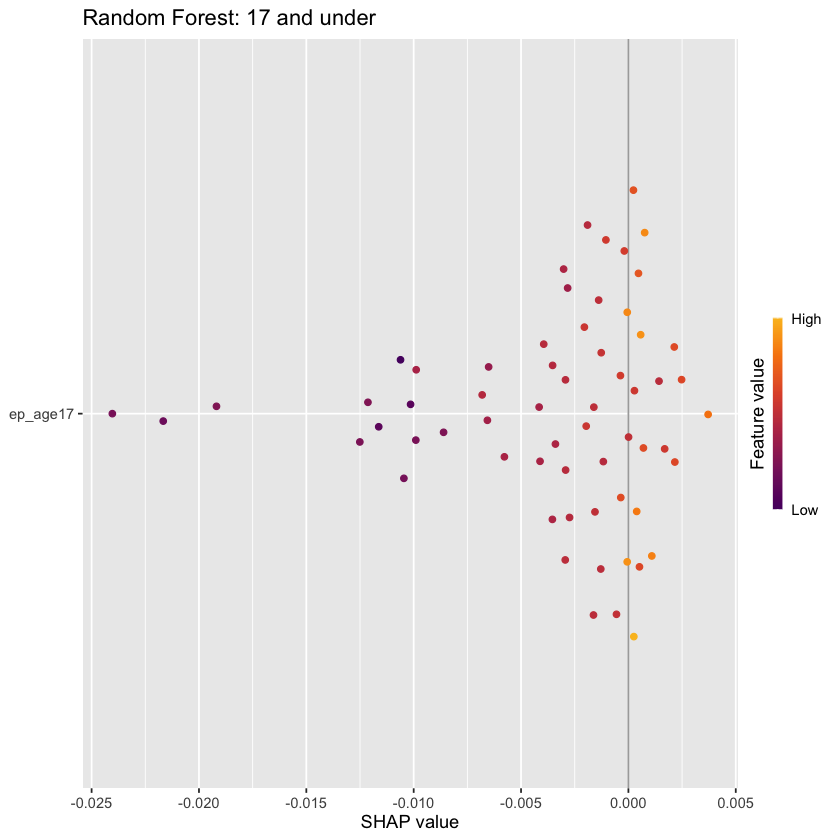

In [196]:
sv_importance(shp_rf_log[, "ep_age17"], kind = "beeswarm", max_display = 20) +
  ggtitle("Random Forest: 17 and under")

For RF: high % of 17 and under contribute FOR an outbreak

In [ ]:
#getting information about ep_otherrace variables
summary(df$ep_otherrace)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.0000  0.1000  0.1827  0.3000  1.7000 

#### Plots of Incorrect Predictions

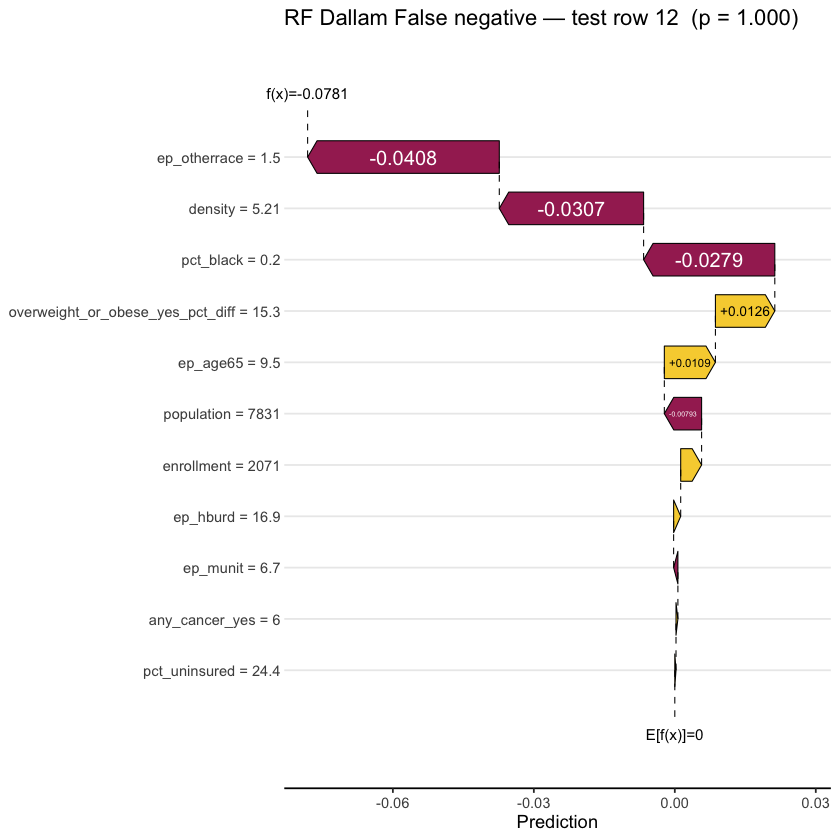

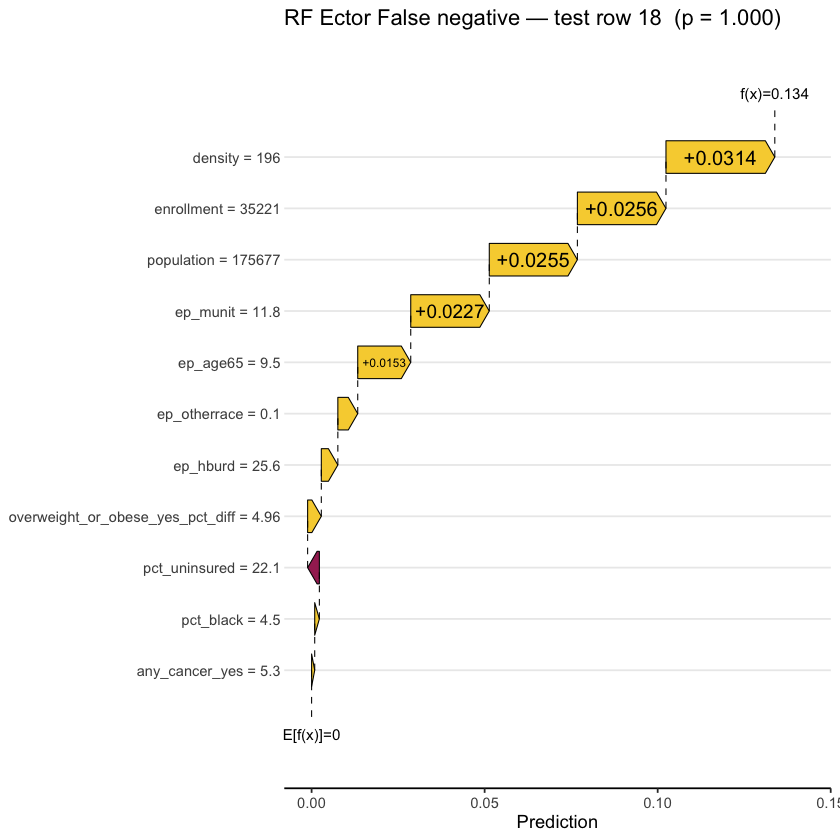

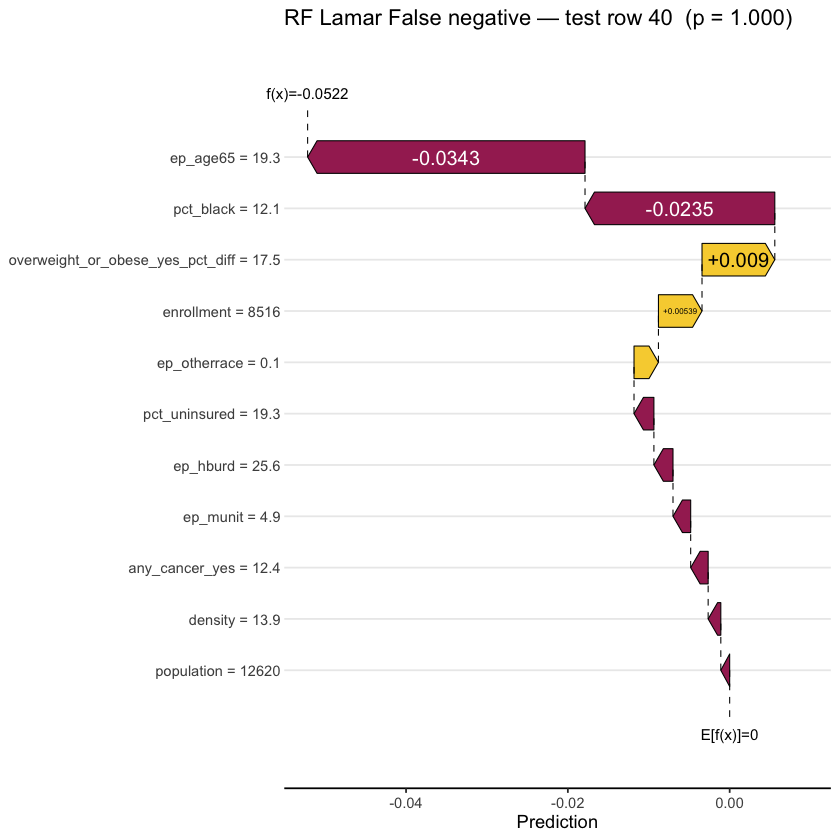

In [ ]:
#False Negatives - Random Forest
fn_ids <- which(y_test == 1 & vect < cutoff)

idx <- 1
sv_waterfall(shp_rf[, vars], row_id = fn_ids[idx], max_display = 20) +
  ggtitle(sprintf("RF Dallam False negative — test row %d  (p = %.3f)", fn_ids[idx], pred_rf[fn_ids[idx]]))

sv_waterfall(shp_rf[, vars], row_id = fn_ids[2], max_display = 20) +
  ggtitle(sprintf("RF Ector False negative — test row %d  (p = %.3f)", fn_ids[2], pred_rf[fn_ids[2]]))

sv_waterfall(shp_rf[, vars], row_id = fn_ids[3], max_display = 20) +
  ggtitle(sprintf("RF Lamar False negative — test row %d  (p = %.3f)", fn_ids[3], pred_rf[fn_ids[3]]))

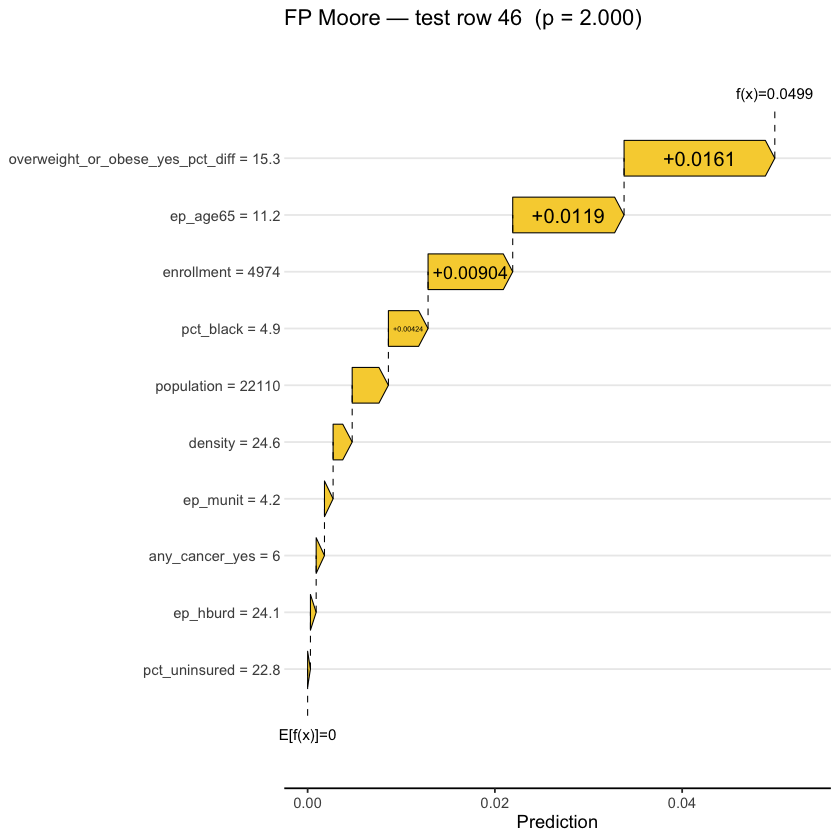

In [ ]:
#False positives - Random Forest
fp_ids <- which(y_test == 0 & vect >= cutoff)
vars <- c("enrollment", "overweight_or_obese_yes_pct_diff", "pct_black", "ep_munit", "ep_age65", "density", "any_cancer_yes", "population", "pct_uninsured", "ep_hburd")
idx <- 1

sv_waterfall(shp_rf[, vars], row_id = fp_ids[idx], max_display = 20) +
  ggtitle(sprintf("FP Moore — test row %d  (p = %.3f)", fp_ids[idx], pred_rf[fp_ids[idx]]))

##### Waterfall plots with enrollment, population, and density after log transformation

[1] 3

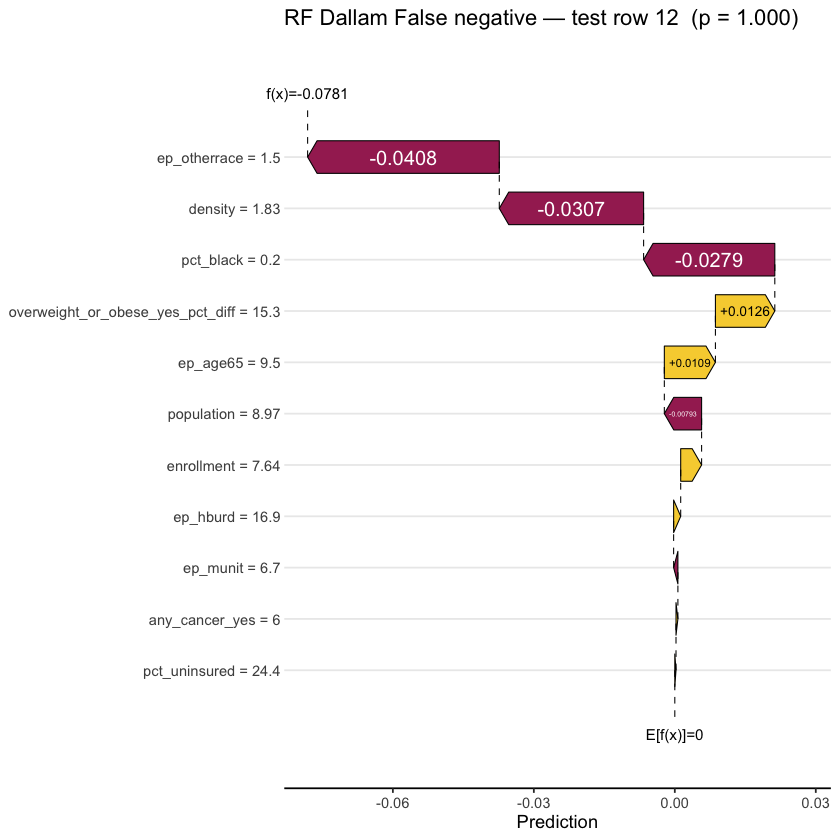

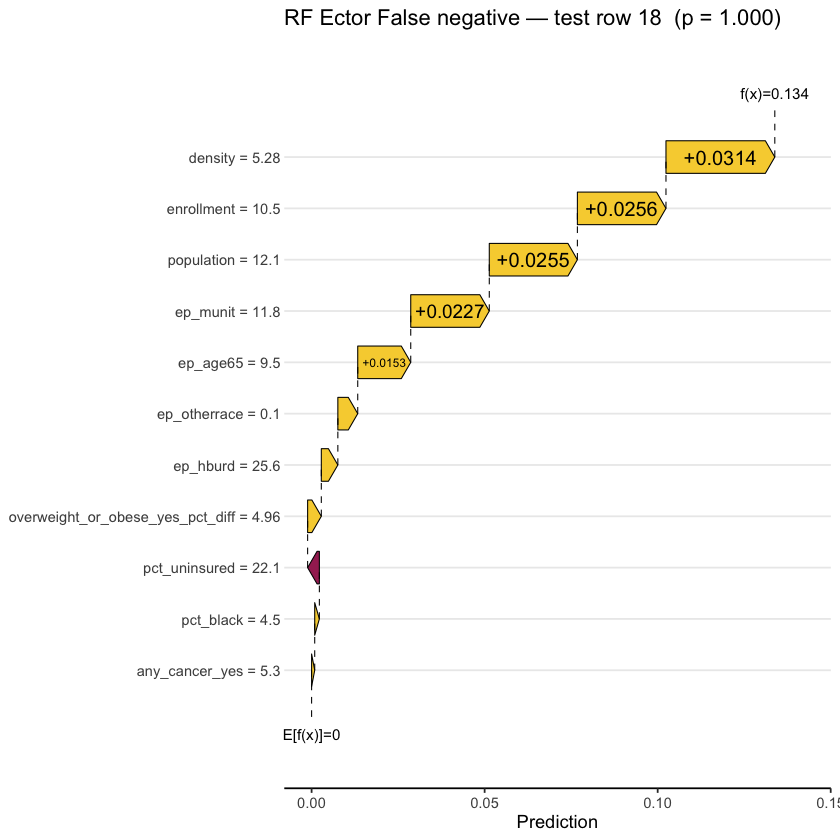

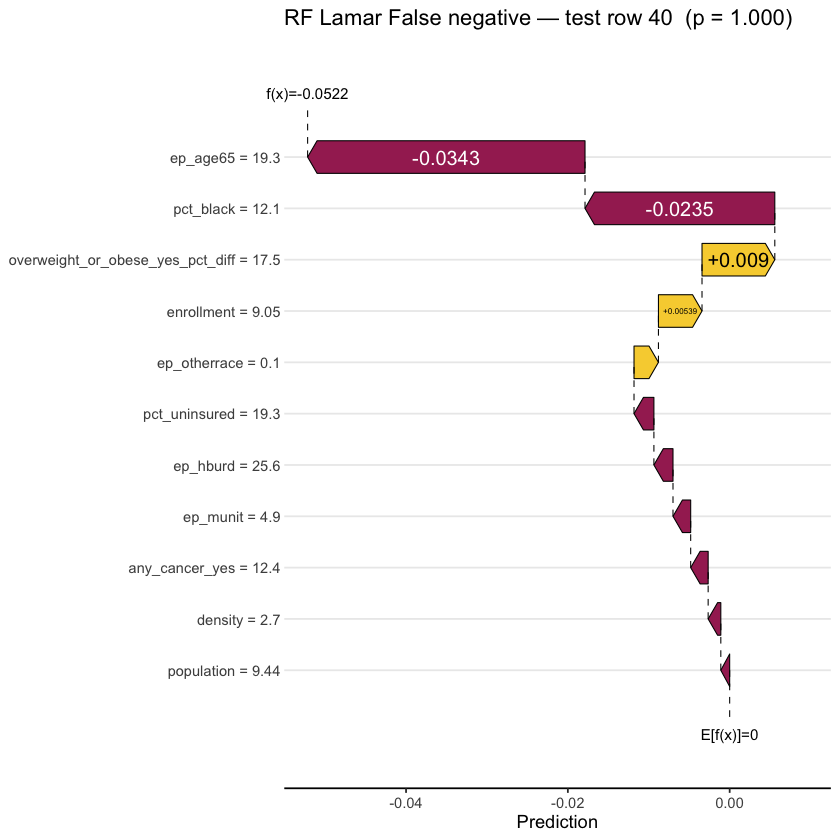

In [ ]:
#False negatives - Random Forest
fn_ids <- which(y_test == 1 & vect < cutoff)
length(fn_ids)

idx <- 1
sv_waterfall(shp_rf_log_vars, row_id = fn_ids[idx], max_display = 20) +
  ggtitle(sprintf("RF Dallam False negative — test row %d  (p = %.3f)", fn_ids[idx], pred_rf[fn_ids[idx]]))

sv_waterfall(shp_rf_log_vars, row_id = fn_ids[2], max_display = 20) +
  ggtitle(sprintf("RF Ector False negative — test row %d  (p = %.3f)", fn_ids[2], pred_rf[fn_ids[2]]))

sv_waterfall(shp_rf_log_vars, row_id = fn_ids[3], max_display = 20) +
  ggtitle(sprintf("RF Lamar False negative — test row %d  (p = %.3f)", fn_ids[3], pred_rf[fn_ids[3]]))

[1] 1

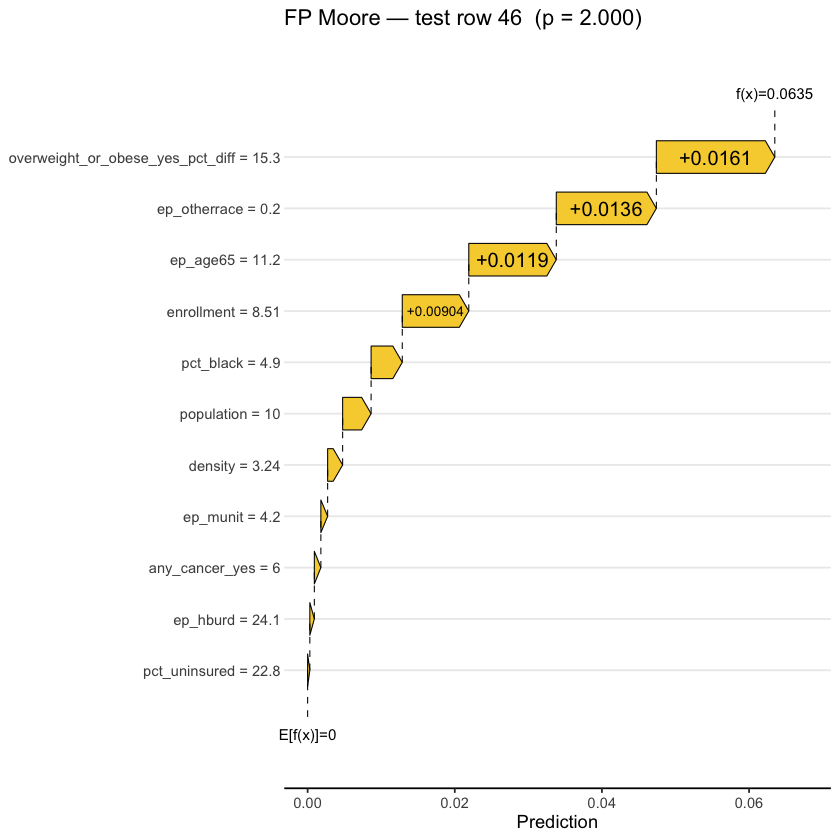

In [ ]:
#False positives - Random Forest
fp_ids <- which(y_test == 0 & vect >= cutoff)
length(fp_ids)
idx <- 1

sv_waterfall(shp_rf_log_vars, row_id = fp_ids[idx], max_display = 20) +
  ggtitle(sprintf("FP Moore — test row %d  (p = %.3f)", fp_ids[idx], pred_rf[fp_ids[idx]]))

#### XGBoost

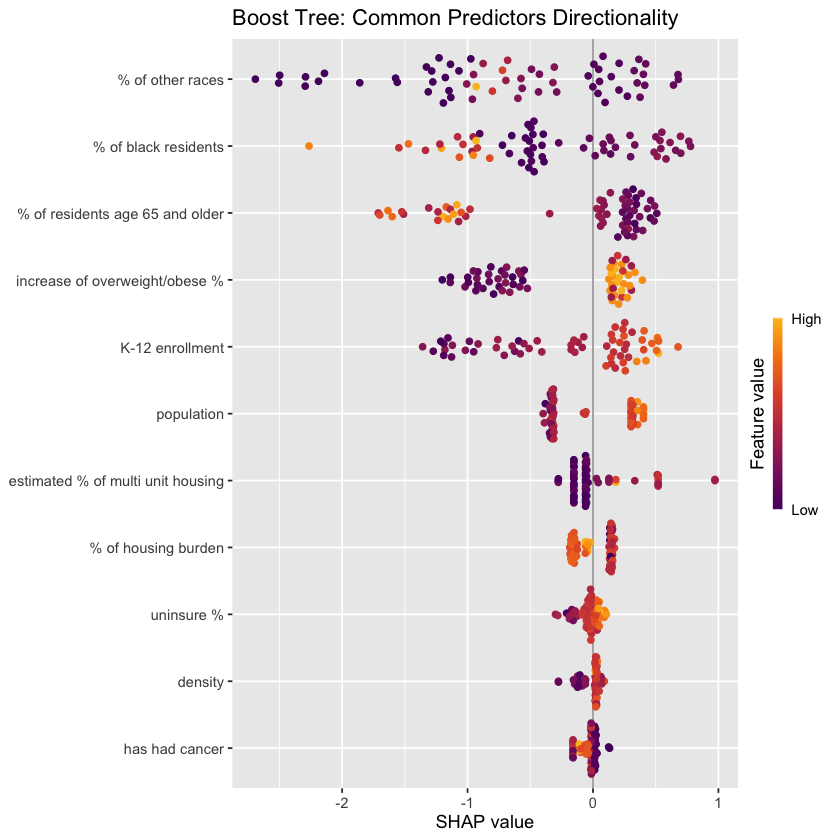

In [204]:
X <- get_feature_values(shp)
log_vars <- intersect(c("enrollment", "density", "population"), colnames(shp))
for (v in log_vars) {
  X[[v]] <- log1p(X[[v]])   # log1p = log(1 + x); avoids -Inf if any value is 0
}

shp_log <- shapviz(
  get_shap_values(shp),
  X        = X,
  baseline = get_baseline(shp)
)

#changing feature names
shp_log_vars <- shp_log[, vars]
colnames(shp_log_vars) <- c("K-12 enrollment",
                            "increase of overweight/obese %",
                            "% of black residents",
                            "estimated % of multi unit housing",
                            "% of residents age 65 and older",
                            "density",
                            "has had cancer",
                            "population",
                            "uninsure %",
                            "% of housing burden",
                            "% of other races")

sv_importance(shp_log_vars, kind = "beeswarm", max_display = 15) +
    ggtitle("Boost Tree: Common Predictors Directionality")

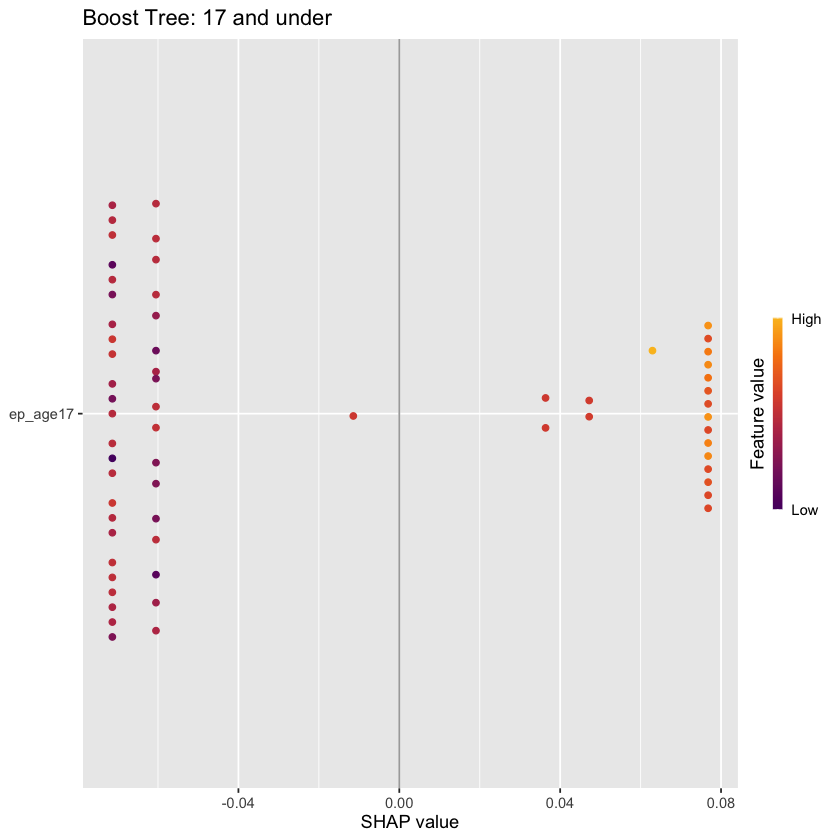

In [205]:
sv_importance(shp_log[, "ep_age17"], kind = "beeswarm", max_display = 15) +
    ggtitle("Boost Tree: 17 and under")

Boost: high % of 17 and under contribute FOR outbreak

[1] 2

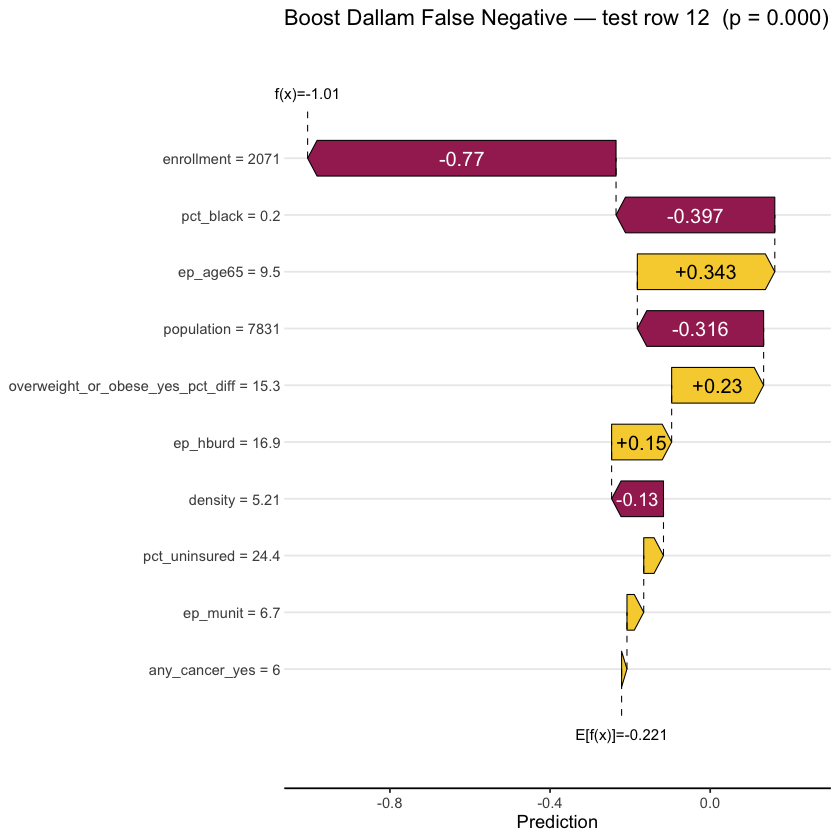

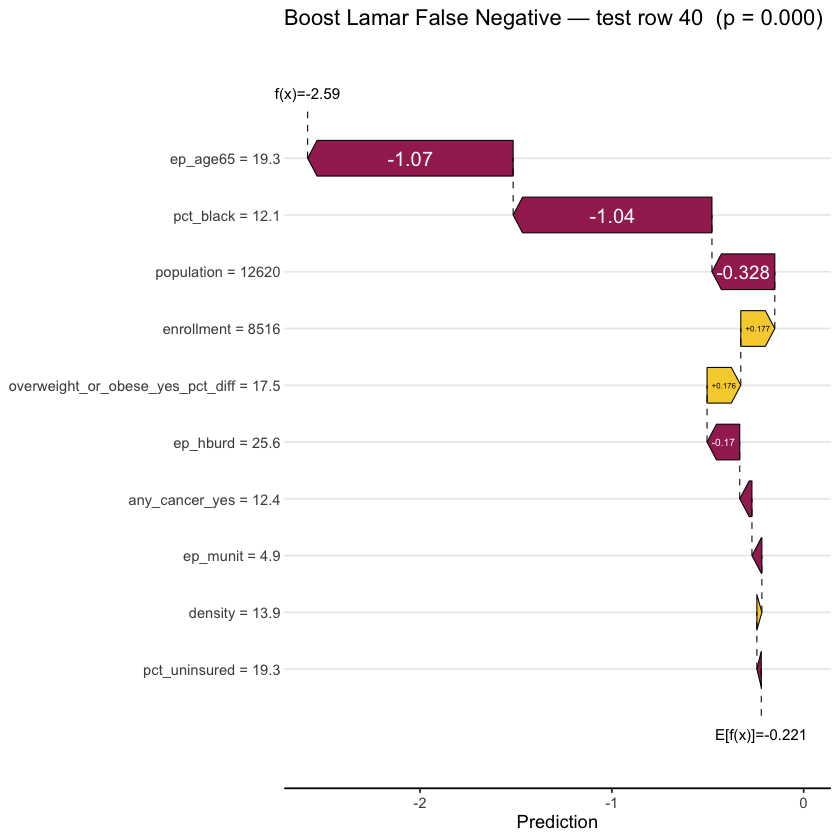

In [ ]:
#False Negatives - XGBoost
fn_ids <- which(y_test == 1 & pred_xgb < cutoff_xgb)
length(fn_ids)
idx <- 1

sv_waterfall(shp[, vars], row_id = fn_ids[idx], max_display = 20) +
  ggtitle(sprintf("Boost Dallam False Negative — test row %d  (p = %.3f)", fn_ids[idx], pred_xgb[fn_ids[idx]]))

sv_waterfall(shp[, vars], row_id = fn_ids[2], max_display = 20) +
  ggtitle(sprintf("Boost Lamar False Negative — test row %d  (p = %.3f)", fn_ids[2], pred_xgb[fn_ids[2]]))

[1] 2

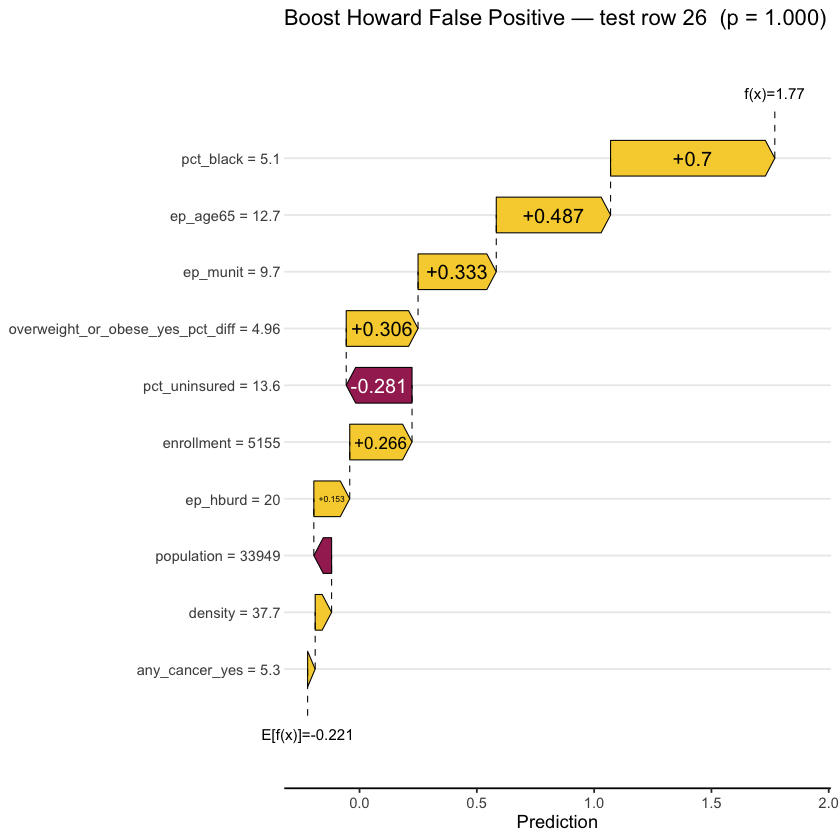

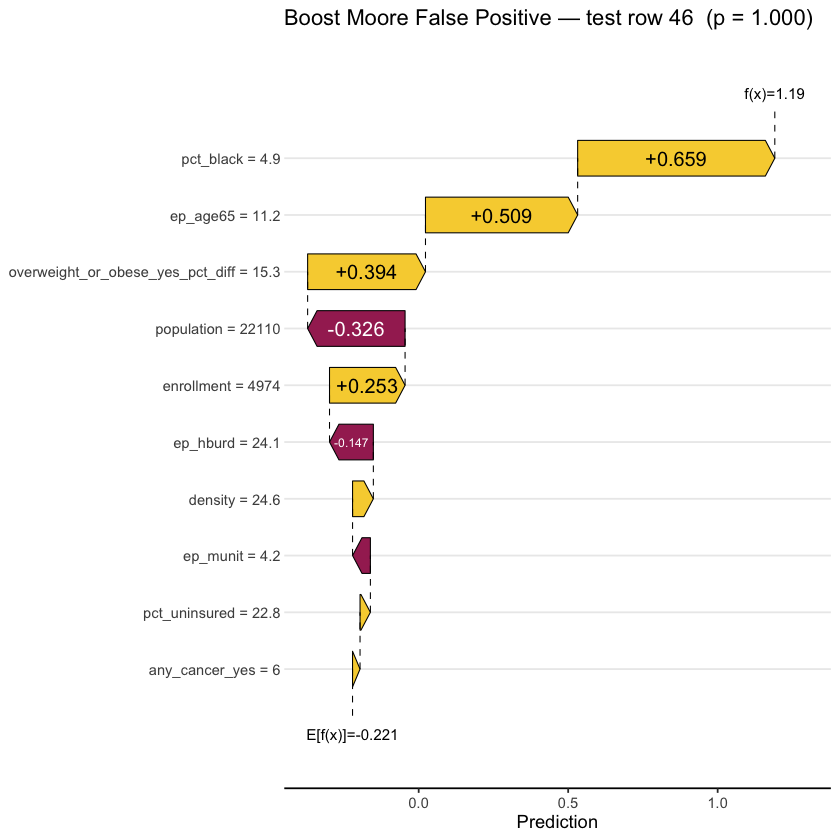

In [ ]:
#False Positives - XGBoost
fp_ids <- which(y_test == 0 & pred_xgb >= cutoff_xgb)
length(fp_ids)
idx <- 1

sv_waterfall(shp[, vars], row_id = fp_ids[idx], max_display = 20) +
  ggtitle(sprintf("Boost Howard False Positive — test row %d  (p = %.3f)", fp_ids[idx], pred_xgb[fp_ids[idx]]))

sv_waterfall(shp[, vars], row_id = fp_ids[2], max_display = 20) +
  ggtitle(sprintf("Boost Moore False Positive — test row %d  (p = %.3f)", fp_ids[2], pred_xgb[fp_ids[2]]))

Waterfall plots with enrollment, population, density log transformed

[1] 2

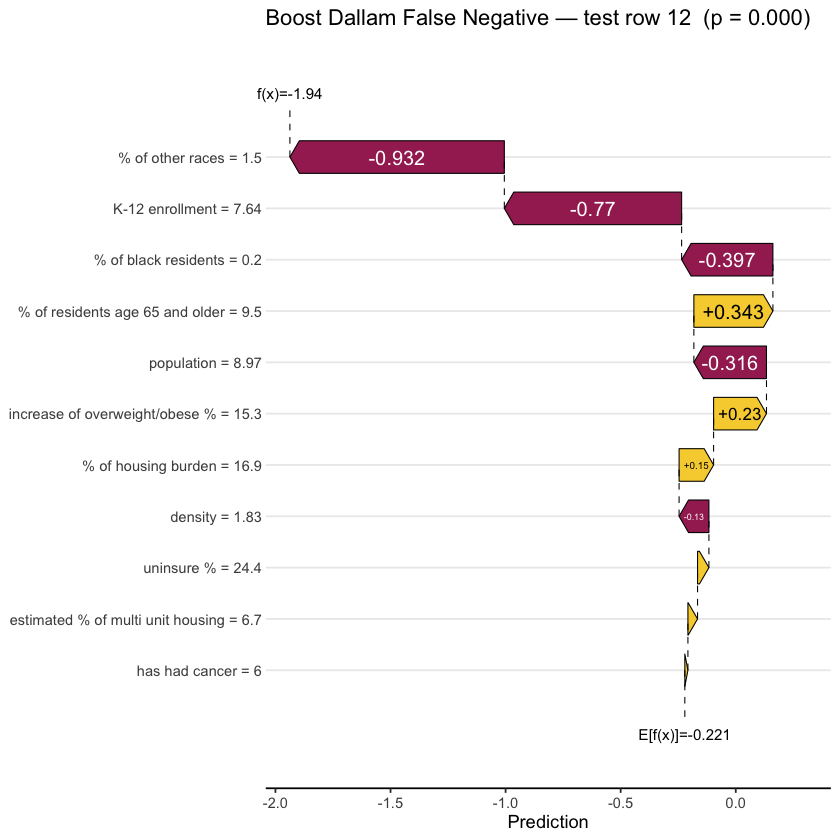

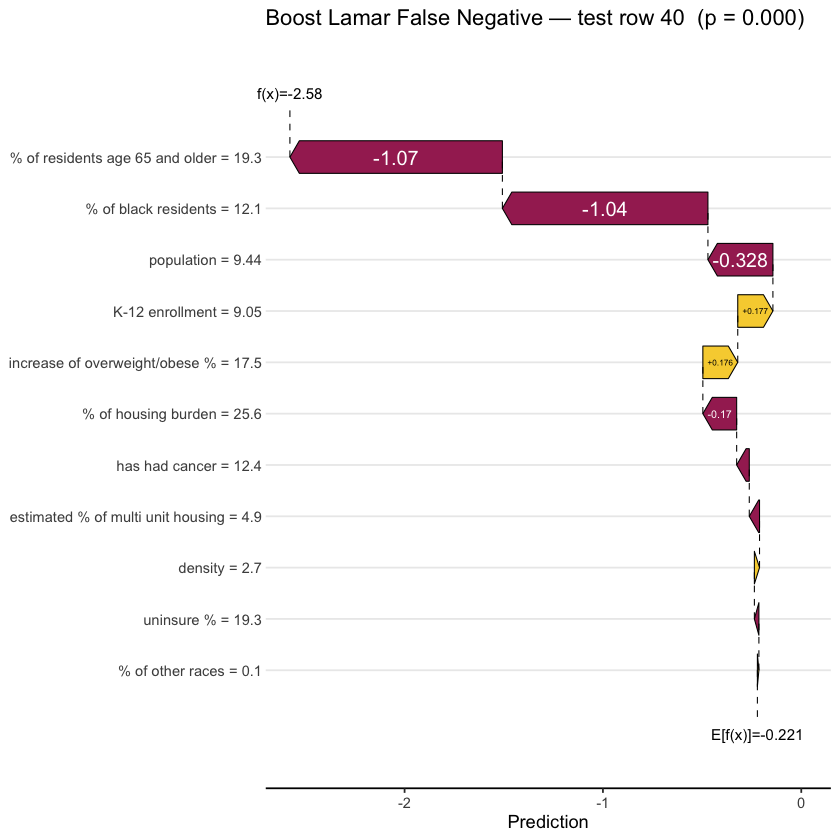

In [ ]:
#False Negatives - XGBoost
fn_ids <- which(y_test == 1 & pred_xgb < cutoff_xgb)
length(fn_ids)
idx <- 1

sv_waterfall(shp_log_vars, row_id = fn_ids[idx], max_display = 20) +
  ggtitle(sprintf("Boost Dallam False Negative — test row %d  (p = %.3f)", fn_ids[idx], pred_xgb[fn_ids[idx]]))

sv_waterfall(shp_log_vars, row_id = fn_ids[2], max_display = 20) +
  ggtitle(sprintf("Boost Lamar False Negative — test row %d  (p = %.3f)", fn_ids[2], pred_xgb[fn_ids[2]]))

[1] 2

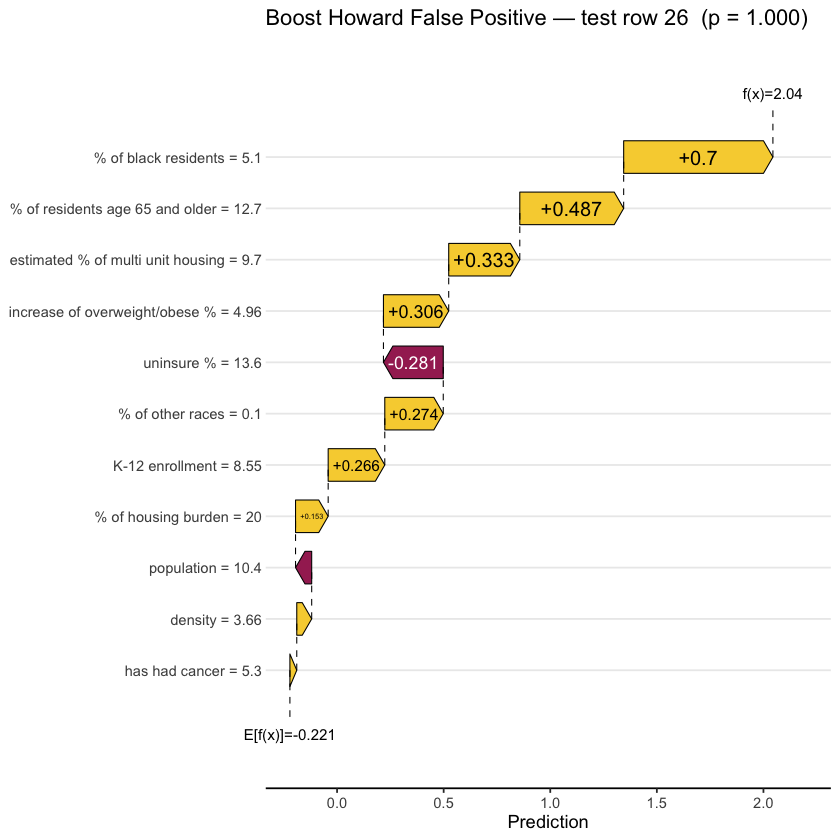

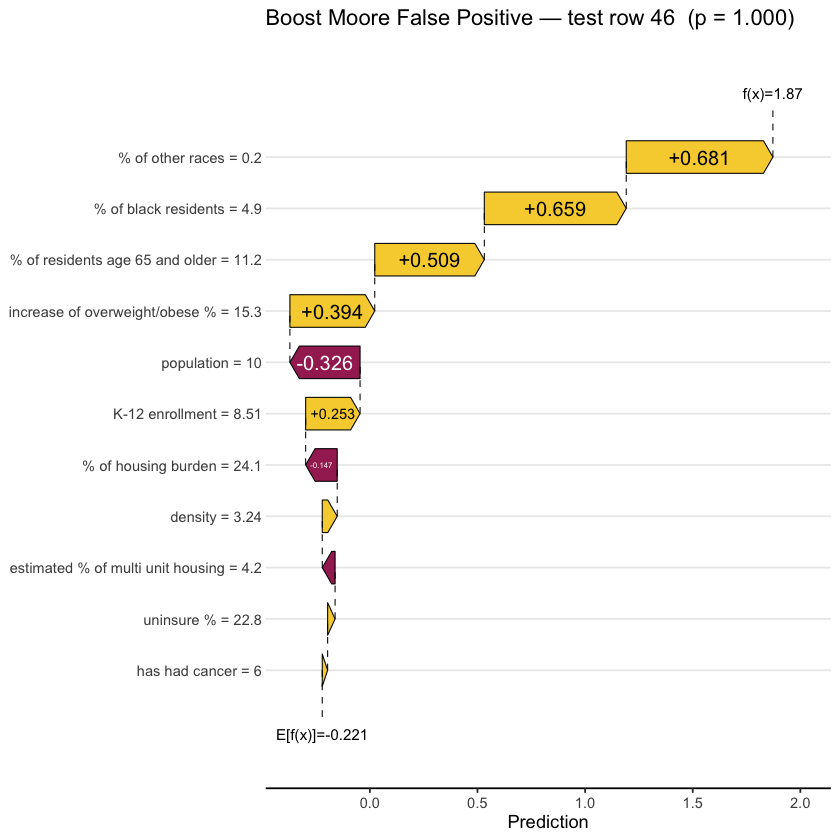

In [ ]:
#False Positive - XGBoost
fp_ids <- which(y_test == 0 & pred_xgb >= cutoff_xgb)
length(fp_ids)
idx <- 1

sv_waterfall(shp_log_vars, row_id = fp_ids[idx], max_display = 20) +
  ggtitle(sprintf("Boost Howard False Positive — test row %d  (p = %.3f)", fp_ids[idx], pred_xgb[fp_ids[idx]]))

sv_waterfall(shp_log_vars, row_id = fp_ids[2], max_display = 20) +
  ggtitle(sprintf("Boost Moore False Positive — test row %d  (p = %.3f)", fp_ids[2], pred_xgb[fp_ids[2]]))

[1] 3

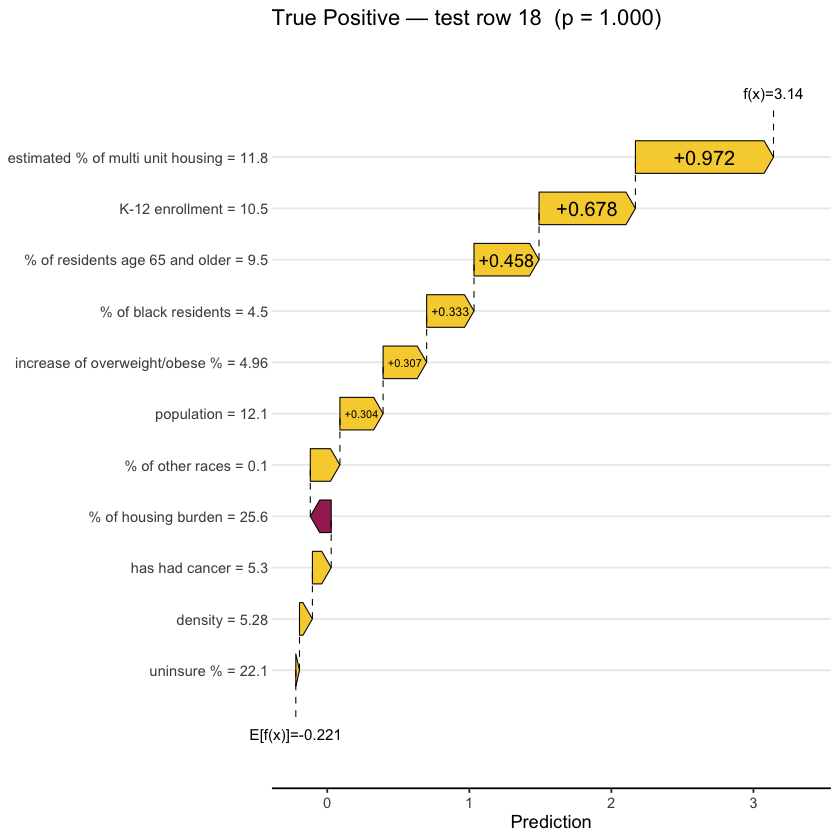

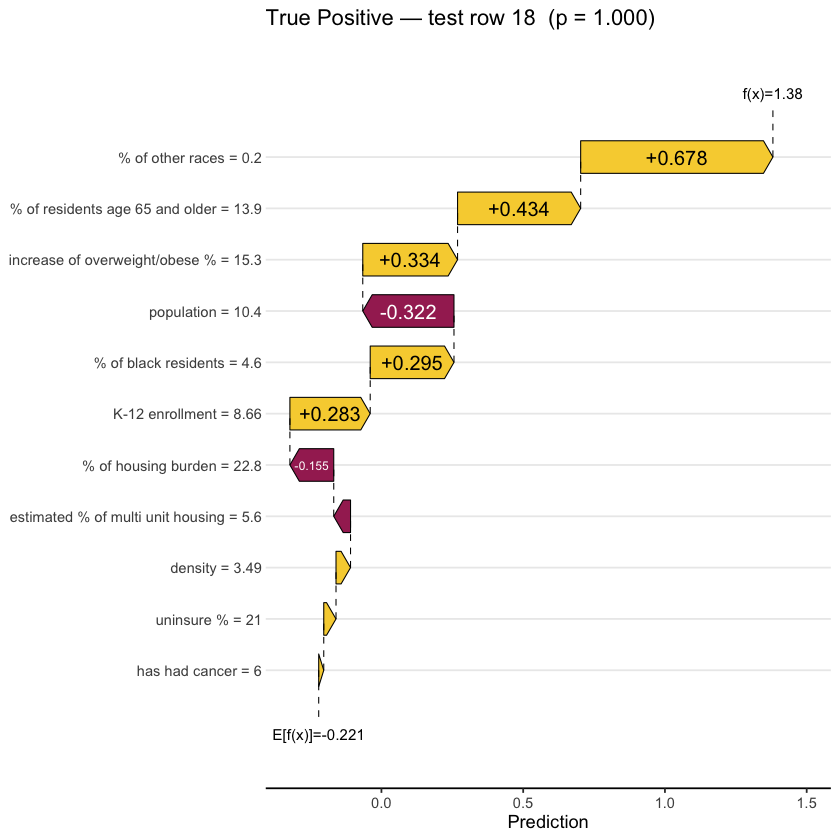

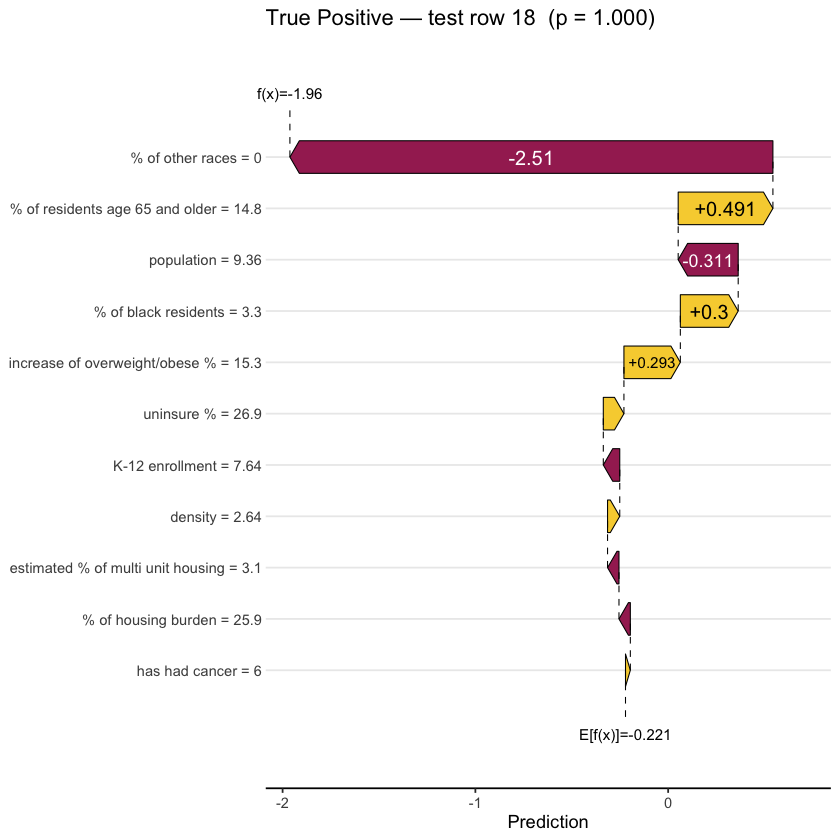

In [211]:
#True positive cases - XGBoost

tp_ids <- which(y_test == 1 & pred_xgb > cutoff_xgb)
length(tp_ids)

sv_waterfall(shp_log_vars, row_id = tp_ids[idx], max_display = 20) +
  ggtitle(sprintf("True Positive — test row %d  (p = %.3f)", tp_ids[idx], pred_xgb[tp_ids[idx]]))

sv_waterfall(shp_log_vars, row_id = tp_ids[2], max_display = 20) +
  ggtitle(sprintf("True Positive — test row %d  (p = %.3f)", tp_ids[idx], pred_xgb[tp_ids[idx]]))

sv_waterfall(shp_log_vars, row_id = tp_ids[3], max_display = 20) +
  ggtitle(sprintf("True Positive — test row %d  (p = %.3f)", tp_ids[idx], pred_xgb[tp_ids[idx]]))  

### SHAP Plot Transformation for Research Poster

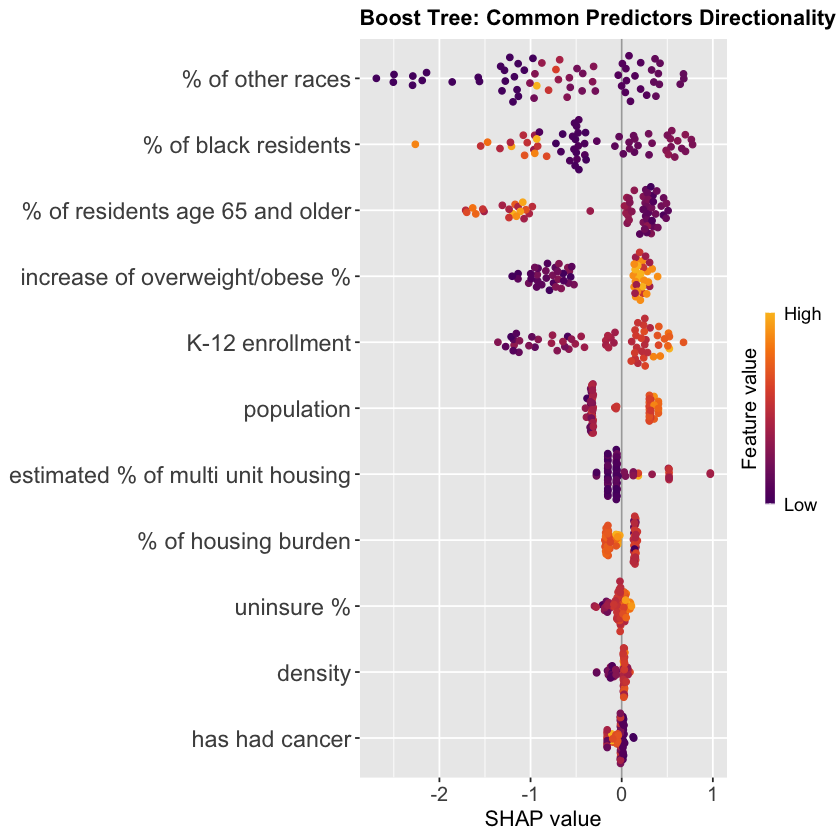

In [206]:
# shp_log_vars2 <- shp_log[, vars2] #includes ep_otherrace
# colnames(shp_log_vars2)<- c("K-12 enrollment", "increase of \n overweight/obese %", "% of black residents","estimated % of \n multi unit housing", "% of residents \n age 65 and older", "density", "has had cancer", "population", "uninsure %", "% of housing burden", "% of other races")

sv_importance(shp_log_vars, kind = "beeswarm", max_display = 15) +
    ggtitle("Boost Tree: Common Predictors Directionality") +
    theme(
        axis.text.y  = element_text(size = 14),   # feature name labels on y-axis
        axis.text.x  = element_text(size = 12),
        axis.title.x = element_text(size = 13),   # "SHAP value" axis label
        plot.title   = element_text(size = 13, face = "bold"),
        legend.text  = element_text(size = 11),   # colorbar tick labels
        legend.title = element_text(size = 12)
    )

In [169]:
ggsave("beeswarm.png", width = 12, height = 7, dpi = 300)

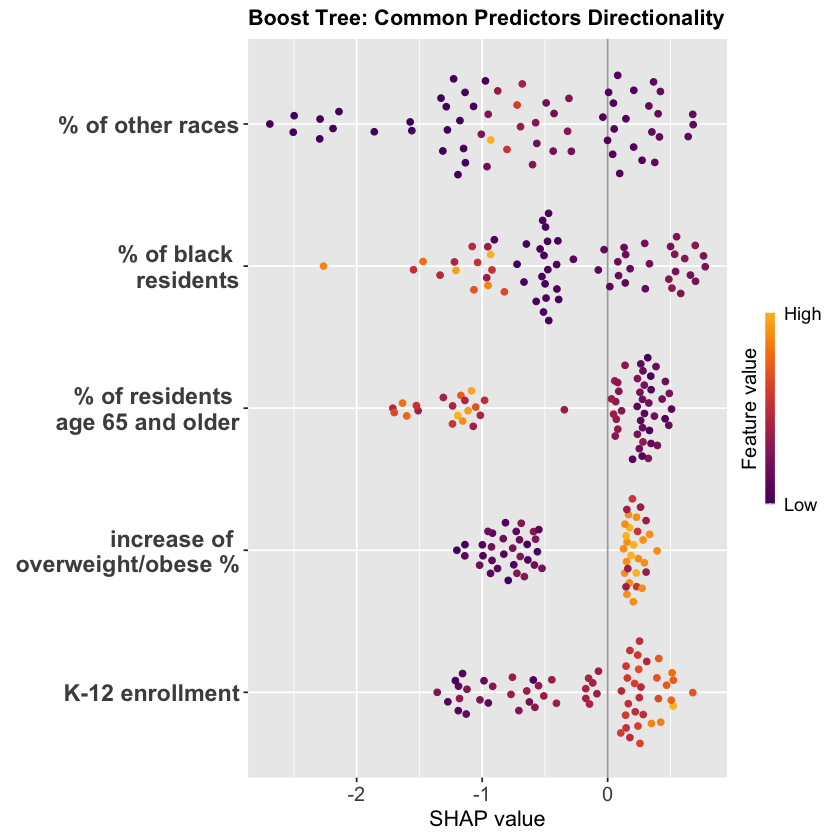

In [ ]:
poster <- c("enrollment", "overweight_or_obese_yes_pct_diff", "pct_black",
            "ep_age65", "ep_otherrace")
shp_poster <- shp_log[, poster]
colnames(shp_poster) <- c("K-12 enrollment", "increase of \n overweight/obese %", "% of black \n residents", "% of residents \n age 65 and older", "% of other races")

sv_importance(shp_poster, kind = "beeswarm", max_display = 15) +
    ggtitle("Boost Tree: Common Predictors Directionality") +
    theme(
        axis.text.y  = element_text(size = 14, face = "bold"),   # feature name labels on y-axis
        axis.text.x  = element_text(size = 12),
        axis.title.x = element_text(size = 13),   # "SHAP value" axis label
        plot.title   = element_text(size = 13, face = "bold"),
        legend.text  = element_text(size = 11),   # colorbar tick labels
        legend.title = element_text(size = 12)
    )


In [184]:
ggsave("beeswarm.png", width = 12, height = 7, dpi = 300)